***

* [总目录](../0_Introduction/0_introduction.ipynb)
* [术语表](../0_Introduction/1_glossary.ipynb)
* [9. 实践部分](9_1_visualisation-inspection.ipynb)
    * 上一节： [9.6 时间平均、频率平均与展宽](9_6_averaging_and_smearing.ipynb)
    * 下一节： [9.x 延伸阅读与后续实践方向](9_x_further_reading_and_workflow.ipynb)

***


导入标准模块:


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import HTML, display
except ImportError:
    HTML = None
    display = None

STYLE_PATH = Path("../style/course.css")
TOGGLE_PATH = Path("../style/code_toggle.html")

if HTML is not None and display is not None:
    if STYLE_PATH.exists():
        display(HTML(f"<style>{STYLE_PATH.read_text(encoding='utf-8')}</style>"))
    if TOGGLE_PATH.exists():
        display(HTML(TOGGLE_PATH.read_text(encoding="utf-8")))

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=3, suppress=True)

RNG = np.random.default_rng(20260421)


## 9.7 谱线数据处理：从连续谱扣除到 PV 图和线宽诊断

谱线实践和连续谱实践最根本的差别在于：我们不再只关心“总带宽里平均有多亮”，而要保留频率轴上的细结构，并把它解释成速度、柱密度和运动学信息。

一个更接近真实工作的基础流程通常包括：

- 先识别 line-free channels，并决定连续谱应采用常数还是低阶基线模型；
- 在频率轴上估计并去除连续谱；
- 得到 line-only data cube；
- 浏览 channel map；
- 用平滑辅助的 3D mask 构造 moment 0 / moment 1 图；
- 抽取 PV diagram；
- 从积分谱线中估计系统速度、`W20/W50` 和单高斯摘要量。

这一节用一个完全自包含的合成 H I 风格数据立方体演示整个过程。它并不替代真实的 `uvcontsub`、`tclean` cube mode、`immoments` 或 `impv`，但会把谱线页从“最小原型”加厚到“更接近专业训练”的层次。


***


In [2]:
c_kms = 299792.458
rest_freq_ghz = 1.42040575


def normalized_gaussian(x, y, x0, y0, sigma_x, sigma_y):
    profile = np.exp(
        -0.5 * (((x - x0) / sigma_x) ** 2 + ((y - y0) / sigma_y) ** 2)
    )
    profile /= profile.sum()
    return profile


def make_beam(npix=56, sigma_pix=1.6):
    coords = np.arange(npix) - npix // 2
    xx, yy = np.meshgrid(coords, coords)
    beam = np.exp(-(xx**2 + yy**2) / (2.0 * sigma_pix**2))
    beam /= beam.max()
    return beam


def fft_convolve_same(image, kernel):
    image_ft = np.fft.fft2(image)
    kernel_ft = np.fft.fft2(np.fft.ifftshift(kernel))
    return np.real(np.fft.ifft2(image_ft * kernel_ft))


def robust_rms(values):
    median = np.median(values)
    return 1.4826 * np.median(np.abs(values - median))


def fit_linear_baseline(cube, velocity_axis, line_free_mask):
    design = np.column_stack(
        [np.ones(line_free_mask.sum()), velocity_axis[line_free_mask]]
    )
    data = cube[line_free_mask].reshape(line_free_mask.sum(), -1)
    coeff, _, _, _ = np.linalg.lstsq(design, data, rcond=None)
    baseline = coeff[0][None, :] + velocity_axis[:, None] * coeff[1][None, :]
    return baseline.reshape((velocity_axis.size, cube.shape[1], cube.shape[2]))


def spectral_smooth(cube):
    padded = np.pad(cube, ((1, 1), (0, 0), (0, 0)), mode="edge")
    return 0.25 * padded[:-2] + 0.5 * padded[1:-1] + 0.25 * padded[2:]


def linewidth_at_fraction(velocity_axis, spectrum, fraction):
    positive = np.clip(spectrum, a_min=0.0, a_max=None)
    peak_idx = int(np.argmax(positive))
    peak = positive[peak_idx]
    level = fraction * peak

    left_candidates = np.where(positive[: peak_idx + 1] < level)[0]
    if left_candidates.size == 0:
        v_left = velocity_axis[0]
    else:
        i0 = left_candidates[-1]
        i1 = min(i0 + 1, peak_idx)
        if positive[i1] == positive[i0]:
            v_left = velocity_axis[i1]
        else:
            v_left = velocity_axis[i0] + (
                (level - positive[i0])
                * (velocity_axis[i1] - velocity_axis[i0])
                / (positive[i1] - positive[i0])
            )

    right_candidates = np.where(positive[peak_idx:] < level)[0]
    if right_candidates.size == 0:
        v_right = velocity_axis[-1]
    else:
        i1 = peak_idx + right_candidates[0]
        i0 = max(peak_idx, i1 - 1)
        if positive[i1] == positive[i0]:
            v_right = velocity_axis[i0]
        else:
            v_right = velocity_axis[i0] + (
                (level - positive[i0])
                * (velocity_axis[i1] - velocity_axis[i0])
                / (positive[i1] - positive[i0])
            )

    return v_right - v_left, 0.5 * (v_left + v_right), level


def fit_single_gaussian_grid(velocity_axis, spectrum, center_guess):
    positive = np.clip(spectrum, a_min=0.0, a_max=None)
    best = None

    for center in np.linspace(center_guess - 18.0, center_guess + 18.0, 121):
        for sigma in np.linspace(4.0, 28.0, 90):
            basis = np.exp(-0.5 * ((velocity_axis - center) / sigma) ** 2)
            amplitude = np.dot(positive, basis) / np.dot(basis, basis)
            amplitude = max(amplitude, 0.0)
            model = amplitude * basis
            chi2 = np.mean((positive - model) ** 2)
            if best is None or chi2 < best[0]:
                best = (chi2, amplitude, center, sigma, model)

    _, _, center_best, sigma_best, _ = best
    for center in np.linspace(center_best - 4.0, center_best + 4.0, 121):
        for sigma in np.linspace(max(2.5, sigma_best - 4.0), sigma_best + 4.0, 121):
            basis = np.exp(-0.5 * ((velocity_axis - center) / sigma) ** 2)
            amplitude = np.dot(positive, basis) / np.dot(basis, basis)
            amplitude = max(amplitude, 0.0)
            model = amplitude * basis
            chi2 = np.mean((positive - model) ** 2)
            if chi2 < best[0]:
                best = (chi2, amplitude, center, sigma, model)

    _, amplitude, center, sigma, model = best
    return amplitude, center, sigma, model


npix = 56
cell_arcsec = 1.5
coords = (np.arange(npix) - npix // 2) * cell_arcsec
x_grid, y_grid = np.meshgrid(coords, coords)

vel_kms = np.linspace(-90.0, 90.0, 49)
freqs_ghz = rest_freq_ghz * (1.0 - vel_kms / c_kms)
dv = np.abs(vel_kms[1] - vel_kms[0])

continuum_map = np.zeros((npix, npix))
center = np.argmin(np.abs(coords - 0.0))
continuum_map[center, center] += 0.36
continuum_map += 0.14 * normalized_gaussian(x_grid, y_grid, 16.0, -12.0, 3.0, 2.5)
continuum_cube = continuum_map[None, :, :] * (1.0 + 0.0013 * vel_kms[:, None, None])

disk_surface = 0.95 * normalized_gaussian(x_grid, y_grid, 3.0, -2.0, 8.0, 5.0)
cloud_surface = 0.22 * normalized_gaussian(x_grid, y_grid, -11.0, 9.0, 3.8, 2.8)
velocity_field = 8.0 + 1.8 * x_grid
cloud_velocity = 28.0 + 0.6 * x_grid
sigma_v = 7.0

line_cube = np.zeros((vel_kms.size, npix, npix))
for ci, vel in enumerate(vel_kms):
    disk_component = disk_surface * np.exp(
        -0.5 * ((vel - velocity_field) / sigma_v) ** 2
    )
    cloud_component = cloud_surface * np.exp(
        -0.5 * ((vel - cloud_velocity) / 4.5) ** 2
    )
    line_cube[ci] = disk_component + cloud_component

beam = make_beam(npix=npix, sigma_pix=1.7)
beam_area_pix = beam.sum()

restored_cube = np.zeros_like(line_cube)
for ci in range(vel_kms.size):
    restored_cube[ci] = fft_convolve_same(continuum_cube[ci] + line_cube[ci], beam)

restored_cube += 0.0035 * RNG.normal(size=restored_cube.shape)

line_free_conservative = np.abs(vel_kms) > 48.0
line_free_loose = np.abs(vel_kms) > 24.0
continuum_mean_loose = restored_cube[line_free_loose].mean(axis=0)
continuum_mean_conservative = restored_cube[line_free_conservative].mean(axis=0)
continuum_linear = fit_linear_baseline(
    restored_cube, vel_kms, line_free_conservative
)

cube_sub_loose = restored_cube - continuum_mean_loose[None, :, :]
cube_sub_mean = restored_cube - continuum_mean_conservative[None, :, :]
cube_sub = restored_cube - continuum_linear

noise_rms = robust_rms(cube_sub[line_free_conservative])
source_aperture = (
    (x_grid - 2.0) ** 2 / 18.0**2 + (y_grid + 1.0) ** 2 / 13.0**2
) < 1.0
background_aperture = ((x_grid + 20.0) ** 2 + (y_grid - 18.0) ** 2) < 7.5**2
spectrum_raw = restored_cube[:, source_aperture].sum(axis=1) / beam_area_pix
spectrum_loose = cube_sub_loose[:, source_aperture].sum(axis=1) / beam_area_pix
spectrum_mean = cube_sub_mean[:, source_aperture].sum(axis=1) / beam_area_pix
spectrum_line = cube_sub[:, source_aperture].sum(axis=1) / beam_area_pix


### 9.7.1 先定义 line-free channels，再决定基线模型

谱线处理里最容易犯的两个错误是：

- 没有先想清楚哪些通道可以视为“只有连续谱，没有谱线”；
- 明明频谱基线存在斜率，却仍然只用常数平均去扣除连续谱。

下面先看积分谱，再比较三种连续谱扣除策略：

- 过于激进的 line-free 选择加上均值法；
- 保守 line-free 选择加上均值法；
- 保守 line-free 选择加上线性基线拟合。

真实处理里更常见的是在可见度域做 `uvcontsub`，并允许低阶多项式拟合。这里的目的，是让你看清楚“通道选择”和“基线模型”是两个独立判断。


保守 line-free 通道数 = 24 / 49
激进 line-free 通道数 = 36 / 49
线外中位残差 [Jy]： 激进均值法 = -0.0252, 保守均值法 = +0.0013, 线性基线 = -0.0012
continuum-subtracted cube 的噪声 RMS ≈ 0.0034 Jy/beam


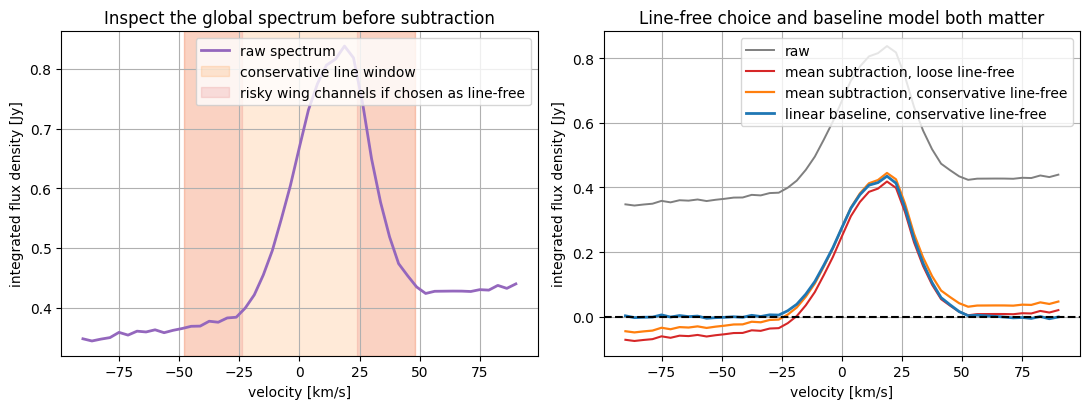

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(vel_kms, spectrum_raw, color="tab:purple", lw=2.0, label="raw spectrum")
axes[0].axvspan(-48.0, 48.0, color="tab:orange", alpha=0.16, label="conservative line window")
axes[0].axvspan(-48.0, -24.0, color="tab:red", alpha=0.12, label="risky wing channels if chosen as line-free")
axes[0].axvspan(24.0, 48.0, color="tab:red", alpha=0.12)
axes[0].set_xlabel("velocity [km/s]")
axes[0].set_ylabel("integrated flux density [Jy]")
axes[0].set_title("Inspect the global spectrum before subtraction")
axes[0].legend(loc="upper right")

axes[1].plot(vel_kms, spectrum_raw, color="tab:gray", lw=1.4, label="raw")
axes[1].plot(vel_kms, spectrum_loose, color="tab:red", lw=1.5, label="mean subtraction, loose line-free")
axes[1].plot(vel_kms, spectrum_mean, color="tab:orange", lw=1.6, label="mean subtraction, conservative line-free")
axes[1].plot(vel_kms, spectrum_line, color="tab:blue", lw=2.0, label="linear baseline, conservative line-free")
axes[1].axhline(0.0, color="black", ls="--")
axes[1].set_xlabel("velocity [km/s]")
axes[1].set_ylabel("integrated flux density [Jy]")
axes[1].set_title("Line-free choice and baseline model both matter")
axes[1].legend(loc="upper right")

plt.tight_layout()
print(f"保守 line-free 通道数 = {line_free_conservative.sum()} / {vel_kms.size}")
print(f"激进 line-free 通道数 = {line_free_loose.sum()} / {vel_kms.size}")
print(
    "线外中位残差 [Jy]："
    f" 激进均值法 = {np.median(spectrum_loose[line_free_conservative]):+.4f},"
    f" 保守均值法 = {np.median(spectrum_mean[line_free_conservative]):+.4f},"
    f" 线性基线 = {np.median(spectrum_line[line_free_conservative]):+.4f}"
)
print(f"continuum-subtracted cube 的噪声 RMS ≈ {noise_rms:.4f} Jy/beam")


从这个对比可以看到两件事：

- 若把线翼误划进 line-free channels，谱线本身会被过度扣除；
- 即使通道选得对，若基线存在频谱斜率，常数均值法仍会留下系统残差。

下面的后续步骤都采用“保守 line-free + 线性基线模型”得到的 `cube_sub`。这一步之后，数据结构才真正变成了可用于谱线分析的 line-only data cube。


### 9.7.2 浏览 channel map：谱线不是一张图，而是一组随速度变化的切片

连续谱图像只有二维，而谱线数据的基本对象是三维立方体。最直接的入口就是 channel map：观察不同速度通道上，发射在空间上如何移动、增强或减弱。


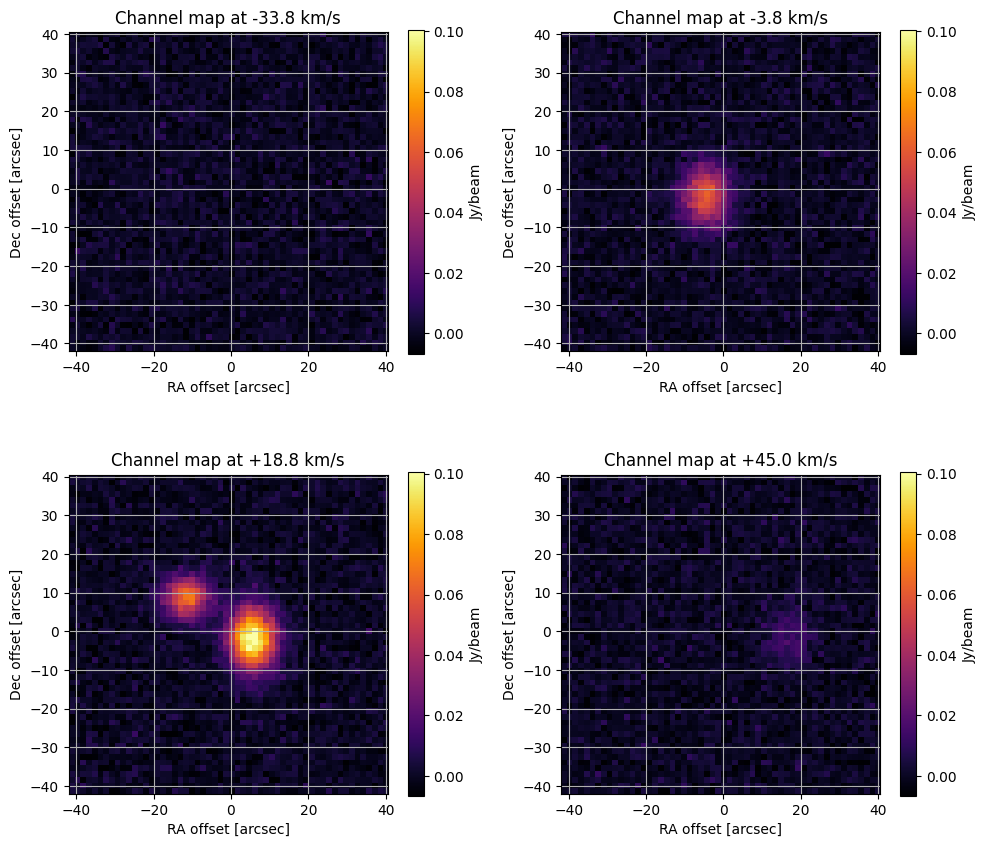

In [4]:
channel_targets = [-35.0, -5.0, 20.0, 45.0]
channel_indices = [np.argmin(np.abs(vel_kms - target)) for target in channel_targets]

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, idx in zip(axes.ravel(), channel_indices):
    im = ax.imshow(
        cube_sub[idx],
        origin="lower",
        extent=[coords[0], coords[-1], coords[0], coords[-1]],
        cmap="inferno",
        vmin=-2.0 * noise_rms,
        vmax=np.max(cube_sub[channel_indices]) * 0.95,
    )
    ax.set_title(f"Channel map at {vel_kms[idx]:+.1f} km/s")
    ax.set_xlabel("RA offset [arcsec]")
    ax.set_ylabel("Dec offset [arcsec]")
    plt.colorbar(im, ax=ax, shrink=0.82, label="Jy/beam")

plt.tight_layout()


这些切片能直接回答一个很重要的问题：发射在不同速度通道上是否沿空间方向系统移动。若答案是肯定的，那么 moment 1 图和 PV 图通常都会呈现出清晰的速度梯度。


### 9.7.3 用平滑辅助的 3D mask 构造 moment 0 与 moment 1 图

若不加筛选就直接对整立方体积分，噪声会严重污染矩图。因此实践里一般会先构造一个 mask，只保留显著探测到发射的体素。

这里采用一个更接近真实工作的简化版思路：

- 先对 cube 做空间与频率平滑；
- 在平滑 cube 上找 2.2-sigma 的种子；
- 要求至少出现在相邻通道中，避免单通道噪声峰；
- 再回到原始 cube，用较低阈值扩展成最终 mask。

这已经是一个简化版的 `moment masking` 思想，比“直接 3-sigma 硬阈值”更稳健，也更接近专业工作流。


平滑后 cube 的 RMS ≈ 0.0092 Jy/beam
进入最终 mask 的体素数 = 5371
背景区域 moment0 平均偏差 [Jy km/s/beam]： 未掩膜 = +0.2838, 掩膜后 = +0.0472


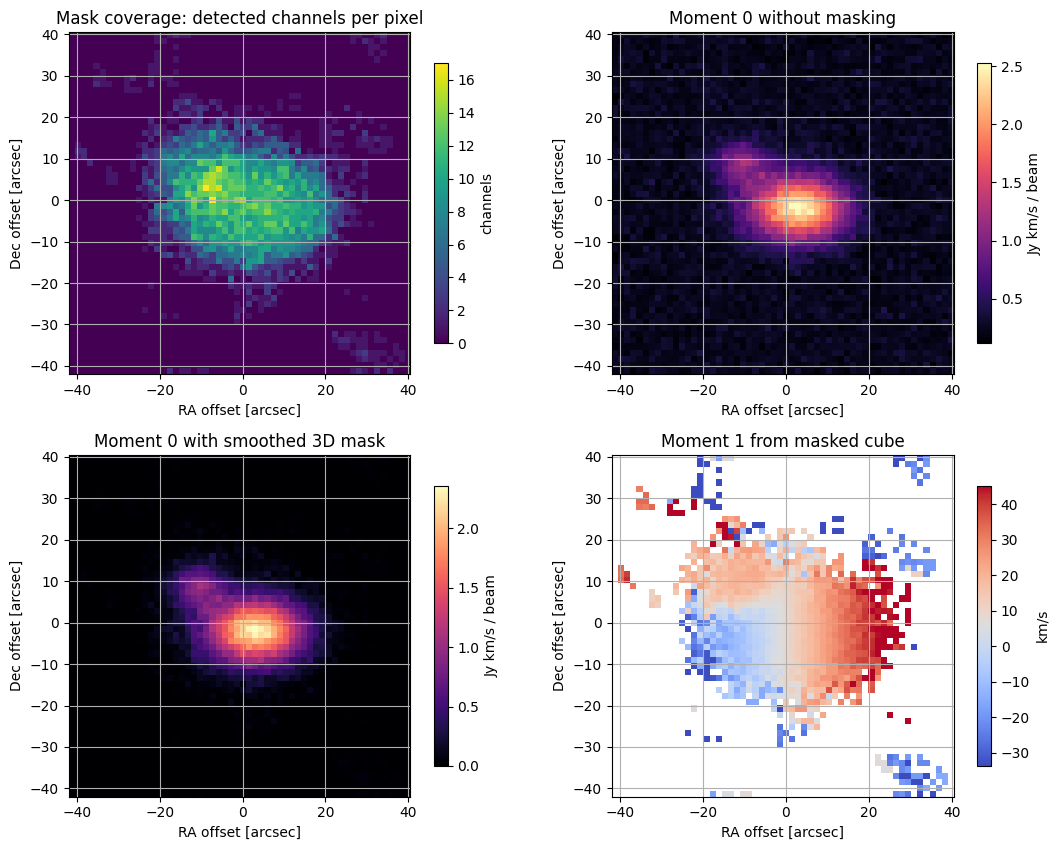

In [5]:
smoothing_beam = make_beam(npix=npix, sigma_pix=2.6)
smooth_cube = np.zeros_like(cube_sub)
for ci in range(vel_kms.size):
    smooth_cube[ci] = fft_convolve_same(cube_sub[ci], smoothing_beam)
smooth_cube = spectral_smooth(smooth_cube)

smoothed_rms = robust_rms(smooth_cube[line_free_conservative])
seed_mask = smooth_cube > (2.2 * smoothed_rms)
neighbor_count = seed_mask.astype(int)
neighbor_count[1:] += seed_mask[:-1]
neighbor_count[:-1] += seed_mask[1:]
spectral_support = neighbor_count >= 2
mask = spectral_support & (cube_sub > (1.2 * noise_rms))

positive_cube = np.clip(cube_sub, a_min=0.0, a_max=None)
masked_positive_cube = np.where(mask, positive_cube, 0.0)
moment0_raw = positive_cube.sum(axis=0) * dv
moment0 = masked_positive_cube.sum(axis=0) * dv
weight_sum = masked_positive_cube.sum(axis=0)
weighted_velocity = (masked_positive_cube * vel_kms[:, None, None]).sum(axis=0)
moment1 = np.full_like(weight_sum, np.nan, dtype=float)
np.divide(weighted_velocity, weight_sum, out=moment1, where=weight_sum > 0.0)
mask_coverage = mask.sum(axis=0)

raw_background_bias = moment0_raw[background_aperture].mean()
masked_background_bias = moment0[background_aperture].mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8.6))

im_mask = axes[0, 0].imshow(
    mask_coverage,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="viridis",
)
axes[0, 0].set_title("Mask coverage: detected channels per pixel")
axes[0, 0].set_xlabel("RA offset [arcsec]")
axes[0, 0].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im_mask, ax=axes[0, 0], shrink=0.82, label="channels")

im0_raw = axes[0, 1].imshow(
    moment0_raw,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="magma",
)
axes[0, 1].set_title("Moment 0 without masking")
axes[0, 1].set_xlabel("RA offset [arcsec]")
axes[0, 1].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im0_raw, ax=axes[0, 1], shrink=0.82, label="Jy km/s / beam")

im0 = axes[1, 0].imshow(
    moment0,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="magma",
)
axes[1, 0].set_title("Moment 0 with smoothed 3D mask")
axes[1, 0].set_xlabel("RA offset [arcsec]")
axes[1, 0].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im0, ax=axes[1, 0], shrink=0.82, label="Jy km/s / beam")

im1 = axes[1, 1].imshow(
    moment1,
    origin="lower",
    extent=[coords[0], coords[-1], coords[0], coords[-1]],
    cmap="coolwarm",
    vmin=np.nanpercentile(moment1, 5),
    vmax=np.nanpercentile(moment1, 95),
)
axes[1, 1].set_title("Moment 1 from masked cube")
axes[1, 1].set_xlabel("RA offset [arcsec]")
axes[1, 1].set_ylabel("Dec offset [arcsec]")
plt.colorbar(im1, ax=axes[1, 1], shrink=0.82, label="km/s")

plt.tight_layout()
print(f"平滑后 cube 的 RMS ≈ {smoothed_rms:.4f} Jy/beam")
print(f"进入最终 mask 的体素数 = {mask.sum()}")
print(
    "背景区域 moment0 平均偏差 [Jy km/s/beam]："
    f" 未掩膜 = {raw_background_bias:+.4f},"
    f" 掩膜后 = {masked_background_bias:+.4f}"
)


这里最值得注意的并不是“我们画出了两张矩图”，而是：**构造掩膜本身已经是谱线分析的一部分。** 未掩膜的 moment 0 图会在空白区域积累正噪声偏差，而平滑辅助的 3D mask 能明显压低这种偏差。


### 9.7.4 沿主轴抽取一个 PV diagram

对旋转盘、外流、双峰结构或速度梯度而言，仅靠 channel map 和 moment 1 往往还不够。一个非常经典、也非常有解释力的诊断量，就是位置-速度图（PV diagram）。

这里沿主轴方向抽取一条有有限宽度的切片。若存在系统性的速度梯度，PV 图通常会呈现出倾斜的脊线。


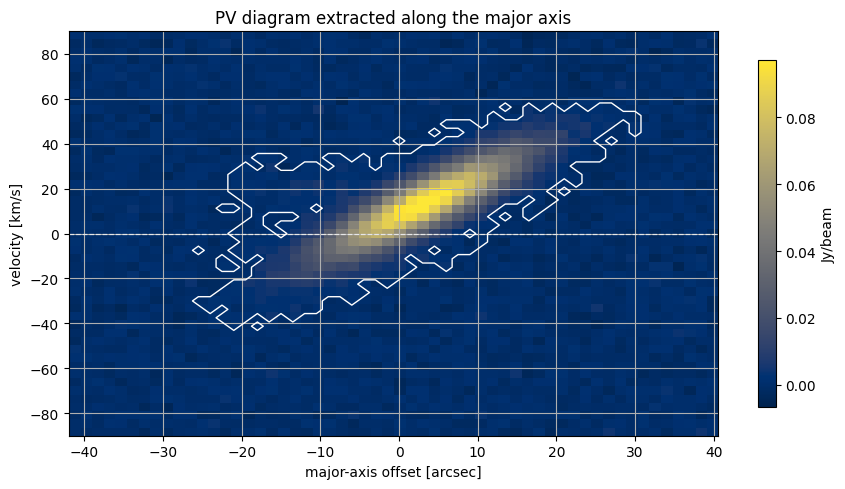

In [6]:
slit_center_dec = -1.5
slit_halfwidth = 3.0
row_select = np.abs(coords - slit_center_dec) <= slit_halfwidth
pv_slice = cube_sub[:, row_select, :].mean(axis=1)
pv_mask = mask[:, row_select, :].any(axis=1).astype(float)

fig, ax = plt.subplots(figsize=(9.0, 5.0))
im = ax.imshow(
    pv_slice,
    origin="lower",
    aspect="auto",
    extent=[coords[0], coords[-1], vel_kms[0], vel_kms[-1]],
    cmap="cividis",
    vmin=-2.0 * noise_rms,
    vmax=np.max(pv_slice) * 0.95,
)
ax.contour(
    coords,
    vel_kms,
    pv_mask,
    levels=[0.5],
    colors="white",
    linewidths=1.0,
)
ax.axhline(0.0, color="white", ls="--", lw=0.9, alpha=0.7)
ax.set_xlabel("major-axis offset [arcsec]")
ax.set_ylabel("velocity [km/s]")
ax.set_title("PV diagram extracted along the major axis")
plt.colorbar(im, ax=ax, shrink=0.86, label="Jy/beam")
plt.tight_layout()


和 moment 1 相比，PV 图往往更容易让你判断：速度梯度是不是单调的、有没有离散云团、是否存在和主盘不同的附加运动学成分。


### 9.7.5 做一个更完整的基础谱线测量：`W20/W50` 与单高斯摘要

下面基于 aperture 内的积分谱线，估计几类最常见的量：

- **系统速度**：谱线强度加权的平均速度；
- **等效 FWHM**：由二阶矩换算出的高斯等效线宽；
- **`W50` / `W20`**：在峰值 50% 和 20% 处测得的轮廓宽度；
- **单高斯摘要**：用一个单峰高斯给出紧凑的中心和宽度摘要。

这里特别保留 `W20/W50`，是因为很多真实全局 H I 轮廓并不接近单高斯，强行只报一个“高斯 FWHM”会把重要形状信息抹掉。


系统速度 ≈ 13.28 km/s
高斯等效 FWHM ≈ 35.42 km/s
W50 ≈ 34.64 km/s，中心速度 ≈ 13.83 km/s
W20 ≈ 52.31 km/s，中心速度 ≈ 12.83 km/s
单高斯摘要中心 ≈ 14.24 km/s，FWHM ≈ 34.34 km/s
积分线通量 ≈ 15.99 Jy km/s


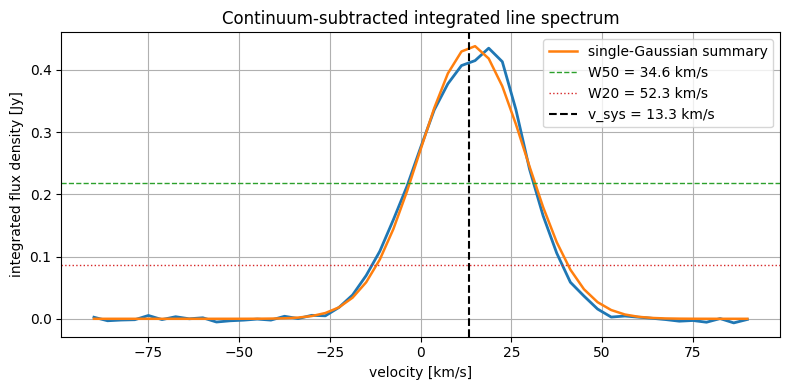

In [7]:
positive_spec = np.clip(spectrum_line, a_min=0.0, a_max=None)
systemic_velocity = np.sum(vel_kms * positive_spec) / np.sum(positive_spec)
sigma_line = np.sqrt(np.sum(positive_spec * (vel_kms - systemic_velocity) ** 2) / np.sum(positive_spec))
fwhm_equiv = 2.355 * sigma_line
w50, v50_center, level50 = linewidth_at_fraction(vel_kms, positive_spec, 0.50)
w20, v20_center, level20 = linewidth_at_fraction(vel_kms, positive_spec, 0.20)
gauss_amp, gauss_center, gauss_sigma, gauss_model = fit_single_gaussian_grid(
    vel_kms, positive_spec, center_guess=systemic_velocity
)
gauss_fwhm = 2.355 * gauss_sigma
integrated_flux = np.sum(positive_spec) * dv

fig, ax = plt.subplots(figsize=(8.0, 4.0))
ax.plot(vel_kms, spectrum_line, color="tab:blue", lw=2.0)
ax.plot(vel_kms, gauss_model, color="tab:orange", lw=1.8, label="single-Gaussian summary")
ax.axhline(level50, color="tab:green", ls="--", lw=1.0, label=f"W50 = {w50:.1f} km/s")
ax.axhline(level20, color="tab:red", ls=":", lw=1.0, label=f"W20 = {w20:.1f} km/s")
ax.axvline(systemic_velocity, color="black", ls="--", label=f"v_sys = {systemic_velocity:.1f} km/s")
ax.set_xlabel("velocity [km/s]")
ax.set_ylabel("integrated flux density [Jy]")
ax.set_title("Continuum-subtracted integrated line spectrum")
ax.legend(loc="upper right")
plt.tight_layout()

print(f"系统速度 ≈ {systemic_velocity:.2f} km/s")
print(f"高斯等效 FWHM ≈ {fwhm_equiv:.2f} km/s")
print(f"W50 ≈ {w50:.2f} km/s，中心速度 ≈ {v50_center:.2f} km/s")
print(f"W20 ≈ {w20:.2f} km/s，中心速度 ≈ {v20_center:.2f} km/s")
print(f"单高斯摘要中心 ≈ {gauss_center:.2f} km/s，FWHM ≈ {gauss_fwhm:.2f} km/s")
print(f"积分线通量 ≈ {integrated_flux:.2f} Jy km/s")


这一组量的用途并不完全相同：

- 二阶矩和单高斯摘要适合快速压缩成“一个中心、一个宽度”；
- `W50/W20` 更接近传统全局轮廓测量，尤其适用于非高斯、双峰或带肩部结构的谱线；
- 若线型明显复杂，下一步通常不应停在摘要量，而要继续做多分量拟合或运动学建模。


### 9.7.6 与真实软件流程的对应

若把这个练习映射到真实软件环境，最常见的谱线处理链大致是：

- `plotms` / `plotbandpass`：先确认 bandpass 与 line-free channels；
- `uvcontsub`：在可见度域做连续谱扣除，必要时加入低阶多项式；
- `tclean`（cube mode）：逐通道成像得到 data cube；
- `immoments` 或更稳健的外部工具：在 mask 基础上构造矩图；
- `impv` 或自定义切片：抽取 PV diagram；
- `specfit` 或自定义测量：估计速度、线宽和积分通量。

这里最重要的专业判断是：**谱线处理不只是“连续谱成像再多一维”。** 它需要更谨慎的频谱基线处理、更明确的 line-free 选择、更有意识的掩膜构造，以及把空间结构和速度结构一起读出来的习惯。
